In [4]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
src = '/content/drive/MyDrive/NEURALHW6/emlak_data.zip'
dst = '/content/'
if not os.path.exists('/content/emlak_data'):
    with zipfile.ZipFile(src) as z:
        z.extractall(dst)
print('emlak_data ready:', os.path.exists('/content/emlak_data/data/images'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
emlak_data ready: True


In [6]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
# True NVIDIA T4

True Tesla T4


# END439E — HOMEWORK 6
## Fine-tuning CLIP for Multimodal Real Estate Search

Damla Hatice Selcuk — 070210730
Elif Kamalak — 070210060
Mertcan El — 820220458



We are building a multimodal property search engine for Istanbul rental listings.
The goal: a user types "ferah mutfakli aydinlik daire" or uploads a photo of a room
they like, and the system returns the most relevant listings.

So in this notebook we tried to roughly practice finetuning CLIP with the sample data we have. Originally we collected listings from both Sahibinden and Emlakjet, but the Sahibinden CSV (scraped by a different teammate using a different scraper) turned out to be too noisy/inconsistent in column formatting, so we dropped it and used only the Emlakjet data we collected ourselves with stealth Playwright. The main problem we had was with the multiple pictures problem for every listing.

We checked out other papers and blogs, githubs of people who also tried this and came up with solutions for the images. This is a scrappy, sloppy notebook of us trying everything for the first time. We discussed with Claude to solve the problem.

**Code sources used throughout:**
- shashnkvats/Indofashionclip (GitHub): finetuning loop, dataset class, clip.load() usage
- Mercari Engineering Blog (Dec 2023): two-round finetuning, mean rank metric
- Maxlconway (Medium, Oct 2024): LoRA concepts

**References**
- Radford et al. (2021). Learning Transferable Visual Models From Natural Language Supervision. ICML.
- Parulekar et al. (2023). InfoNCE Loss Provably Learns Cluster-Preserving Representations. arXiv.
- Wang & Isola (2020). Understanding Contrastive Representation Learning through Alignment and Uniformity. ICML.
- Hasan et al. (2024). A Multi-Modal Deep Learning Based Approach for House Price Prediction. arXiv:2409.05335.
- Srinivasan et al. (2024). Addressing Modality Mismatch in Real Estate Recommendation. IEEE FMLDS.
- Feng et al. (2023). MKVSE: Multimodal Knowledge Enhanced Visual-semantic Embedding. ACM TOMM.
- Rosen (1974). Hedonic prices and implicit markets. Journal of Political Economy.


## 0. Setup

In [7]:
import os, re, json, time, warnings
from pathlib import Path
from io import BytesIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import clip

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
BLUE, ORANGE, GREEN, PURPLE = '#2563EB', '#EA580C', '#16A34A', '#7C3AED'

# Paths -- single base, derive everything from it
BASE       = Path('/content')
EMLAK_RAW  = BASE / 'emlak_data' / 'data' / 'raw'
EMLAK_IMGS = BASE / 'emlak_data' / 'data' / 'images'

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Base: {BASE}')


Device: cuda
PyTorch: 2.10.0+cu128
Base: /content


---
## 1. The Problem: Multiple Photos Per Listing

When we first tried to fine-tune CLIP on our Emlakjet data,
we ran into a problem we had not thought about: every listing has multiple photos.

A typical Istanbul rental listing looks like this:
- Photo 0: exterior of the building
- Photo 1: living room
- Photo 2: kitchen
- Photo 3: bathroom
- Photo 4: bedroom
- Photo 5: balcony view

CLIP expects one image and one text per training sample. But which photo
should we pair with "3+1, merkezi ısıtmalı, site içinde kiralık daire"?

If we use only the first photo, the model never sees the kitchen or balcony.
If we use all photos separately, each gets the same text and the model has to learn
that a photo of a bathroom is "similar" to "site içinde" which makes no semantic sense.
If we pool the embeddings somehow, we need to decide when and how.

This is not a new problem. We found four approaches in the literature,
implemented three of them, and compared using a metric that needs no manual labels.

### Four approaches from the literature

**Approach A - Single photo (baseline)**
Use only the first photo. Fast but loses most information.

**Approach B - Each photo as a separate training sample**
From shashnkvats/Indofashionclip (GitHub): every (image, text) pair is one sample.
A listing with 3 photos contributes 3 training samples, all with the same text.
The model learns that different rooms of the same apartment should all be close
to that apartment's text description.

**Approach C - Mean pooling (Srinivasan et al., 2024)**
From "Addressing Modality Mismatch in Real Estate Recommendation" (IEEE FMLDS 2024):
encode each photo separately with CLIP, then average the 512d embeddings.

$$\mathbf{e}_{\text{listing}} = \text{normalize}\left(\frac{1}{N}\sum_{i=1}^{N} \mathbf{e}_{\text{photo}_i}\right)$$

This is semantic averaging and not pixel averaging.
The result captures "this apartment has a kitchen AND a bathroom AND a balcony feature."

**Approach D - Knowledge graph (Feng et al., 2023 — MKVSE)**
Build a Multimodal Knowledge Graph (MKG) from Visual Genome (300 visual objects)
and WordNet semantic relations. Use Graph Convolutional Networks to bridge the gap
between what appears in photos and what is written in text descriptions.

We studied MKVSE carefully but did not implement it for two reasons:
1. It requires object detection on all photos to extract visual entities
2. Our dataset (~2400 listings) is too small for GCN training to converge

Instead, we address the same modality gap with text enrichment:
including categorical features (rooms, size, heating, furnished) in the text prompt
so the model learns to associate visual room appearances with property specs.


---
## 2. Dataset: Emlakjet (stealth-Playwright scrape)

We use the Emlakjet listings we scraped ourselves with stealth Playwright.
The dataset contains 1472 listings, with photos already downloaded to `emlak_data/data/images/<id>/` (one folder per listing).
A second source — Sahibinden, scraped by a teammate with a different scraper — was originally part of the project but its CSV format was inconsistent enough that combining it with Emlakjet hurt training, so we dropped it.

Each listing in `listings.jsonl` carries a `title`, `description`, `price`, structured attributes (e.g. `roomCount`), and a list of image URLs (used as fallback when the local images directory is missing).


In [8]:
# Sahibinden source dropped (CSV from a different scraper had inconsistent column formatting).
# We use only the Emlakjet data scraped with stealth Playwright; loading happens in the next cell.


In [9]:
# ── Emlakjet ───────────────────────────────────────────────────────────────
# EMLAK_RAW and EMLAK_IMGS come from the setup block in Cell 2.

emlak_records = []
with open(EMLAK_RAW / 'listings.jsonl', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            emlak_records.append(json.loads(line))
print(f'Emlakjet raw records: {len(emlak_records)}')

def parse_price_emlak(s):
    if not s: return np.nan
    s = str(s).replace(' TL','').replace('.','').replace(',','').strip()
    m = re.search(r'\d+', s)
    return float(m.group()) if m else np.nan

def parse_rooms_emlak(s):
    if not s: return np.nan
    m = re.match(r'(\d+)\+(\d+)', str(s).strip())
    return int(m.group(1)) + int(m.group(2)) if m else np.nan

def parse_size_from_title(title):
    if not title: return np.nan
    m = re.search(r'(\d{2,4})\s*m2', str(title), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

emlak_rows = []
for rec in emlak_records:
    attrs = rec.get('attributes', {})
    lid   = str(rec.get('id', ''))
    idir  = EMLAK_IMGS / lid
    emlak_rows.append({
        'price_tl':   parse_price_emlak(rec.get('price', '')),
        'size_m2':    parse_size_from_title(rec.get('title', '')),
        'room_count': parse_rooms_emlak(attrs.get('roomCount', '')),
        'title':      rec.get('title', ''),
        'aciklama':   rec.get('description', ''),
        'esyali':     '',
        'isitma':     '',
        'source':     'emlakjet',
        'image_urls': rec.get('image_urls', []),
        'image_dir':  str(idir) if idir.exists() else None,
    })

emlak = pd.DataFrame(emlak_rows)
emlak = emlak[emlak['price_tl'].between(5000, 1000000)].reset_index(drop=True)
print(f'Emlakjet: {len(emlak)} listings')
print(f'With local images: {emlak["image_dir"].notna().sum()}')


Emlakjet raw records: 1472
Emlakjet: 1470 listings
With local images: 1464


In [10]:
# ── Build the working dataframe (Emlakjet only) ────────────────────────────
df = emlak.copy()
df['listing_id'] = range(len(df))

# Text enrichment: combine title + categorical features + description
# Practical alternative to the MKVSE knowledge graph: include structured
# features in the prompt so the model bridges the visual-textual gap.
df['text_prompt'] = (
    df['title'].fillna('') + '. ' +
    'Oda: ' + df['room_count'].fillna(0).astype(int).astype(str) + '+1, ' +
    df['size_m2'].fillna(0).astype(int).astype(str) + 'm2. ' +
    df['aciklama'].fillna('').str[:150]
)

# Image sources: prefer local paths, fall back to URLs if a listing's local dir is missing.
def get_image_sources(row, max_photos=3):
    if row['image_dir']:
        d = Path(row['image_dir'])
        if d.exists():
            return [str(p) for p in sorted(d.glob('*.jpg'))[:max_photos]]
    return row['image_urls'][:max_photos]

df['image_sources'] = df.apply(get_image_sources, axis=1)
df['n_images']      = df['image_sources'].str.len()

print(f'Emlakjet listings: {len(df)}')
print(f'  With images:      {(df.n_images > 0).sum()}')
print(f'  Avg photos/listing: {df.n_images.mean():.1f}')


Emlakjet listings: 1470
  With images:      1372
  Avg photos/listing: 2.8


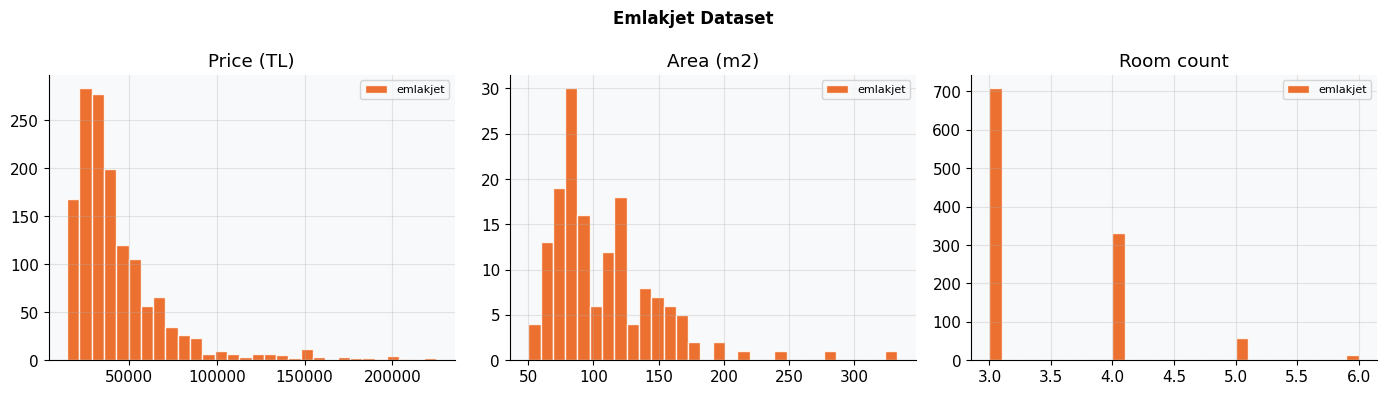

In [11]:
# EDA
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Emlakjet Dataset', fontsize=12, fontweight='bold')
for ax, col, title in zip(axes,
    ['price_tl', 'size_m2', 'room_count'],
    ['Price (TL)', 'Area (m2)', 'Room count']):
    s = df[col].dropna()
    if len(s) == 0:
        continue
    s = s[(s > s.quantile(0.01)) & (s < s.quantile(0.99))]
    ax.hist(s, bins=30, alpha=0.85, color=ORANGE, label='emlakjet', edgecolor='white')
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=130, bbox_inches='tight')
plt.show()


## 3. Neural Network Architecture — CLIP ViT-B/32

### 3.1 Why CLIP and not a shallow network

In HW4 we built a shallow network: 1 hidden layer, 3 units, 2 inputs, 13 parameters.
It mapped (ln(sqm), rooms) → ln(price). It cannot do retrieval.

Our goal is different: find listings similar to a text query or a photo.
This requires a shared embedding space where images and text live together.
CLIP (Radford et al., 2021) does exactly this — trained on 400 million (image, text) pairs.

We load CLIP following shashnkvats/Indofashionclip:
```python
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
```

The detailed architecture (dimensions, hidden layers, input-output relations) and a code-block-by-code-block walkthrough are given in **Section 3A** (Question 1).
The loss function and optimizer choices are deferred to **Section 8A** (Question 2).


In [12]:
# Load CLIP -- following shashnkvats/Indofashionclip
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()

total_params  = sum(p.numel() for p in model.parameters())
visual_params = sum(p.numel() for p in model.visual.parameters())
text_params   = total_params - visual_params

arch = pd.DataFrame([
    {'Component': 'Vision Encoder (ViT-B/32)',
     'Parameters': f'{visual_params:,}',
     'Input': '224x224x3', 'Output': '512d embedding',
     'Detail': '12 layers, 12 heads, 768 hidden'},
    {'Component': 'Text Encoder (Transformer)',
     'Parameters': f'{text_params:,}',
     'Input': '77 tokens', 'Output': '512d embedding',
     'Detail': '12 layers, 8 heads, 512 hidden'},
    {'Component': 'Shared embedding space',
     'Parameters': '—',
     'Input': 'image or text', 'Output': '512d L2-normalized',
     'Detail': 'cosine similarity is meaningful'},
]).set_index('Component')
display(arch)
print(f'\nTotal: {total_params:,} parameters')
print(f'HW4 shallow network: 13 parameters ({total_params//13:,}x smaller)')


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 96.6MiB/s]


,Parameters,Input,Output,Detail
Component,,,,
Vision Encoder (ViT-B/32),"87,849,216",224x224x3,512d embedding,"12 layers, 12 heads, 768 hidden"
Text Encoder (Transformer),"63,428,097",77 tokens,512d embedding,"12 layers, 8 heads, 512 hidden"
Shared embedding space,—,image or text,512d L2-normalized,cosine similarity is meaningful



Total: 151,277,313 parameters
HW4 shallow network: 13 parameters (11,636,716x smaller)


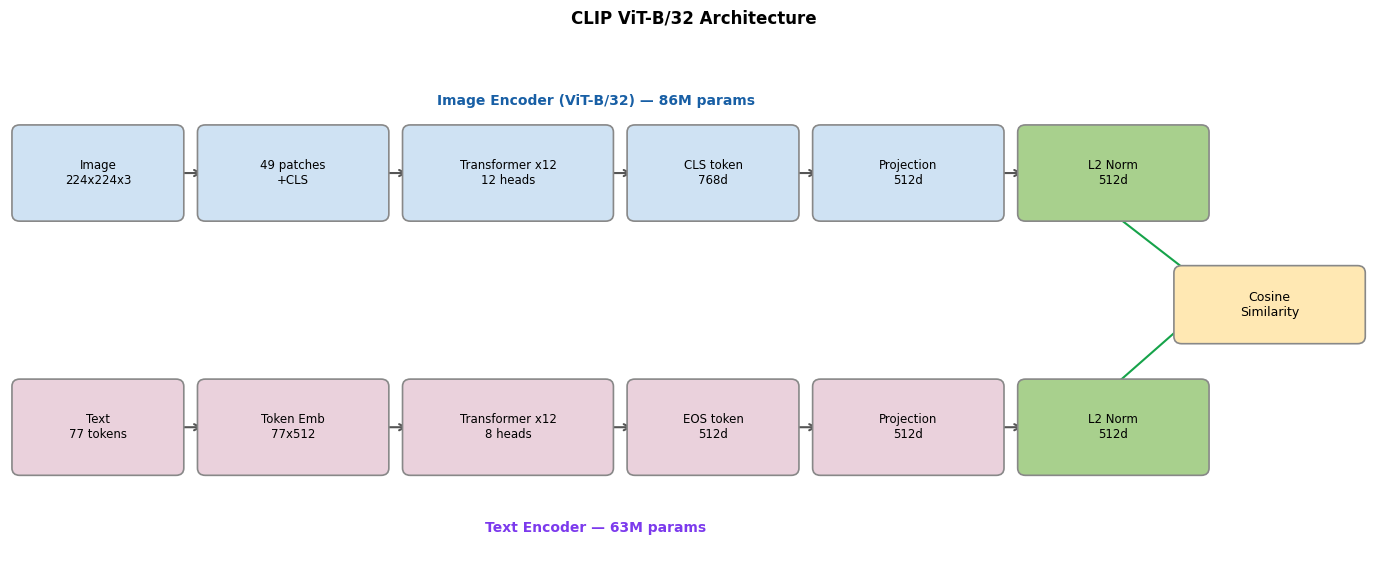

In [13]:
# Architecture diagram
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off'); ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax.set_xlim(0,14); ax.set_ylim(0,6)

def box(ax, x, y, w, h, text, fc, fs=8.5):
    b = mpatches.FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.08',
        facecolor=fc, edgecolor='#888', linewidth=1.2, zorder=3)
    ax.add_patch(b)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center',
            fontsize=fs, zorder=4, multialignment='center')

def arr(ax, x1, y1, x2, y2, color='#555'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=2)

img_steps = [
    (0.1, 4.0, 1.6, 0.9, 'Image\n224x224x3', '#CFE2F3'),
    (2.0, 4.0, 1.8, 0.9, '49 patches\n+CLS', '#CFE2F3'),
    (4.1, 4.0, 2.0, 0.9, 'Transformer x12\n12 heads', '#CFE2F3'),
    (6.4, 4.0, 1.6, 0.9, 'CLS token\n768d', '#CFE2F3'),
    (8.3, 4.0, 1.8, 0.9, 'Projection\n512d', '#CFE2F3'),
    (10.4, 4.0, 1.8, 0.9, 'L2 Norm\n512d', '#A8D08D'),
]
for x,y,w,h,t,fc in img_steps:
    box(ax, x, y, w, h, t, fc)
for i in range(len(img_steps)-1):
    arr(ax, img_steps[i][0]+img_steps[i][2], img_steps[i][1]+0.45,
        img_steps[i+1][0], img_steps[i+1][1]+0.45)
ax.text(6, 5.2, 'Image Encoder (ViT-B/32) — 86M params',
        ha='center', fontsize=10, color='#185FA5', fontweight='bold')

txt_steps = [
    (0.1, 1.2, 1.6, 0.9, 'Text\n77 tokens', '#EAD1DC'),
    (2.0, 1.2, 1.8, 0.9, 'Token Emb\n77x512', '#EAD1DC'),
    (4.1, 1.2, 2.0, 0.9, 'Transformer x12\n8 heads', '#EAD1DC'),
    (6.4, 1.2, 1.6, 0.9, 'EOS token\n512d', '#EAD1DC'),
    (8.3, 1.2, 1.8, 0.9, 'Projection\n512d', '#EAD1DC'),
    (10.4, 1.2, 1.8, 0.9, 'L2 Norm\n512d', '#A8D08D'),
]
for x,y,w,h,t,fc in txt_steps:
    box(ax, x, y, w, h, t, fc)
for i in range(len(txt_steps)-1):
    arr(ax, txt_steps[i][0]+txt_steps[i][2], txt_steps[i][1]+0.45,
        txt_steps[i+1][0], txt_steps[i+1][1]+0.45)
ax.text(6, 0.5, 'Text Encoder — 63M params',
        ha='center', fontsize=10, color='#7C3AED', fontweight='bold')

arr(ax, 11.3, 4.0, 12.2, 3.25, '#16A34A')
arr(ax, 11.3, 2.1, 12.2, 2.95, '#16A34A')
box(ax, 12.0, 2.65, 1.8, 0.7, 'Cosine\nSimilarity', '#FFE8B3', fs=9)
ax.set_title('CLIP ViT-B/32 Architecture', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_architecture.png', dpi=150, bbox_inches='tight')
plt.show()


## 3A. Question 1 / First Neural Network Model: Architecture and Code Blocks

> **Homework Q1:** Upload the first neural network model from your project. Explain each piece of code block depending on solution-oriented implementation and discuss the neural network architecture including dimensions, hidden layers and input-output relations. (Optimization steps are *not* discussed here — see Section 8A.)

### What model is uploaded for Q1
The first neural network model in our project is **CLIP ViT-B/32** (Radford et al., 2021), loaded with `clip.load("ViT-B/32", ...)` in Cell 10. The shallow HW4 network (1 hidden layer, 3 units, 13 parameters) maps tabular features to a scalar price; it cannot do retrieval. Our project goal is *cross-modal retrieval* — given a Turkish text query or a room photo, return the most relevant Istanbul rental listings — so we need both modalities to live in the same vector space. CLIP is exactly that: two encoders trained to project images and text into a shared `R^512` space where matching pairs have high cosine similarity.

---

### Architecture: dimensions, hidden layers, and input-output relations

#### A) Vision encoder — ViT-B/32 (12 Transformer blocks, ~86M params)
- **Input:** RGB image, resized and CLIP-preprocessed to `224 x 224 x 3`.
- **Patchification:** image is split into non-overlapping `32 x 32` patches -> `(224/32)^2 = 49` patches; one learnable `[CLS]` token is prepended -> sequence length 50.
- **Hidden depth:** **12 Transformer encoder layers**, hidden size **768**, **12 attention heads**.
- **Pooling:** the final-layer `[CLS]` representation (768d) is taken as the image embedding.
- **Projection head:** linear projection 768d -> **512d**, then L2-normalize.
- **Output:** unit vector in `R^512`.

`image -> 49 patches + CLS -> 12x Transformer (768d, 12 heads) -> CLS (768d) -> Linear -> 512d -> L2`

#### B) Text encoder — Transformer (12 blocks, ~63M params)
- **Input:** raw string tokenized by CLIP's BPE; max length **77 tokens** (hard CLIP limit, hence `truncate=True`).
- **Embedding:** token + positional embeddings of width **512**.
- **Hidden depth:** **12 Transformer layers**, hidden size **512**, **8 attention heads**.
- **Pooling:** the hidden state at the end-of-text (`[EOS]`) position is taken as the text representation.
- **Projection head:** linear 512d -> **512d**, then L2-normalize.
- **Output:** unit vector in `R^512`.

`text -> tokenize(<=77) -> 12x Transformer (512d, 8 heads) -> EOS (512d) -> Linear -> 512d -> L2`

#### C) Shared embedding space and the input-output relation
Both encoders emit unit-norm vectors in the same `R^512` space, so

`similarity(v_image, v_text) = v_image . v_text = cos(v_image, v_text) in [-1, 1]`

This is the core input-output relation that powers our retrieval system: encode once, compare with a dot product. For a corpus of N listings we precompute a `(N, 512)` text matrix; a query (image or text) is encoded to a single `(512,)` vector and ranked by dot product against the matrix.

---

### Code-block-by-code-block explanation (in execution order)

The blocks below correspond, top to bottom, to Cells 10 and 14 of this notebook.

#### Block 1 — Load the pretrained model (Cell 10)
```python
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model.eval()
```
- `clip.load("ViT-B/32", ...)` downloads/loads pretrained weights and returns the model **plus** the CLIP-specific image preprocessing pipeline (resize to 224, center-crop, CLIP RGB normalization). We must use this exact `preprocess` because the visual encoder was trained with it.
- `jit=False` returns a regular `nn.Module` so we can later flip `requires_grad` flags and fine-tune.
- `model.eval()` disables dropout for the zero-shot encoding stage that follows.

#### Block 2 — Parameter inspection (Cell 10)
```python
total_params  = sum(p.numel() for p in model.parameters())
visual_params = sum(p.numel() for p in model.visual.parameters())
text_params   = total_params - visual_params
```
- Confirms the architecture scale (~150M params total: ~86M visual + ~63M text), which the table built right below this block displays. This is the number we contrast with HW4's 13-parameter MLP to motivate the model choice.

#### Block 3 — Robust image loader `load_image_from_source` (Cell 14)
```python
def load_image_from_source(src, preprocess_fn):
    if str(src).startswith('http'):
        r = requests.get(src, timeout=8, headers={'User-Agent': 'Mozilla/5.0'})
        img = Image.open(BytesIO(r.content)).convert('RGB')
    else:
        img = Image.open(src).convert('RGB')
    return preprocess_fn(img)
```
- Solution-oriented detail: most Emlakjet listings have local images in `emlak_data/data/images/<id>/`, but a handful are missing from disk and only the original image URLs survive in `listings.jsonl`. One helper handles both branches transparently.
- On failure (missing local file or broken URL) it returns a neutral grey 224x224 image so a single corrupt sample does not crash a whole training epoch or eval pass.
- Output shape: `(3, 224, 224)` tensor ready for `model.encode_image`.

#### Block 4 — Text encoder wrapper `encode_text_corpus` (Cell 14)
```python
tokens = clip.tokenize(texts[i:i+batch], truncate=True).to(device)
embs   = model.encode_text(tokens)
embs   = F.normalize(embs.float(), dim=-1)
```
- Walks the listing corpus in batches of 64 to bound GPU memory.
- `clip.tokenize(..., truncate=True)` enforces the 77-token cap; our enriched prompts (title + rooms + size + first 150 chars of description) routinely overshoot, so truncation is mandatory.
- `F.normalize(..., dim=-1)` is what turns the dot product into a cosine — it's the precondition for the similarity formula above.
- Output shape: `(N, 512)`.

#### Block 5 — Single-image encoder `encode_single_image` (Cell 14)
```python
img_t = load_image_from_source(src, preprocess_fn).unsqueeze(0).to(device)
emb   = model.encode_image(img_t)
emb   = F.normalize(emb.float(), dim=-1)
return emb.squeeze(0).cpu()
```
- One image -> one 512d unit vector. Used both as the Approach-A baseline (first photo only) and as a building block for pooling strategies.
- `.float()` upcasts CLIP's internal fp16 buffers (when on GPU) to fp32 before normalization for numerical stability.

#### Block 6 — Multi-photo aggregation `encode_mean_pool` (Cell 14)
```python
embs = [encode_single_image(s, model, preprocess_fn) for s in sources]
pooled = torch.stack(embs).mean(dim=0)
return F.normalize(pooled, dim=0)
```
- This is our solution to the "multiple photos per listing" problem we discuss in Section 1.
- Averaging happens in **embedding space**, not pixel space. Semantically, the mean vector represents "this apartment has all these visual features at once" — exactly the additive semantics CLIP's contrastive training induces (Srinivasan et al., 2024).
- A final renormalization re-projects the average back onto the unit sphere so cosine similarity remains the right comparison.

#### Block 7 — Identity-retrieval evaluator `identity_retrieval` (Cell 14)
```python
sims = (text_matrix @ img_emb)
rank = (sims >= sims[idx]).sum().item()
```
- Not part of the model itself, but the function that turns model outputs into a measurable signal: for each listing's image embedding, find the rank of its own text among all N text embeddings. Since `text_matrix` rows and `img_emb` are both unit-norm, the matrix-vector product is a length-N cosine similarity vector.
- Reports `mean_rank` and `Recall@{1, 5, 10}` — the metrics we use throughout Sections 5 and 7.

---

### Architecture summary table

| Component | Hidden depth | Width / heads | Input | Output |
|---|---|---|---|---|
| Vision encoder (ViT-B/32) | 12 Transformer blocks | 768d, 12 heads | 224x224x3 image | 512d unit vector |
| Text encoder (Transformer) | 12 Transformer blocks | 512d, 8 heads | <=77 BPE tokens | 512d unit vector |
| Shared retrieval space | — | — | image *or* text embedding | cosine similarity |

This is the model uploaded for Question 1. Loss function and optimization choices are intentionally deferred to Section 8A, per the homework instruction.

---
## 4. Encoding Functions

In [14]:
def load_image_from_source(src, preprocess_fn):
    """Load PIL Image from local path or URL, apply CLIP preprocessing."""
    try:
        if str(src).startswith('http'):
            r = requests.get(src, timeout=8,
                headers={'User-Agent': 'Mozilla/5.0'})
            if r.status_code != 200:
                raise Exception('bad status')
            img = Image.open(BytesIO(r.content)).convert('RGB')
        else:
            img = Image.open(src).convert('RGB')
        return preprocess_fn(img)
    except Exception:
        return preprocess_fn(Image.new('RGB', (224,224), (128,128,128)))

def encode_text_corpus(texts, model, batch=64):
    """
    Encode list of texts with CLIP text encoder.
    Input:  list of strings
    Output: (N, 512) L2-normalized tensor
    Architecture: tokenize -> 12-layer transformer -> 512d embedding
    """
    all_embs = []
    for i in range(0, len(texts), batch):
        with torch.no_grad():
            tokens = clip.tokenize(texts[i:i+batch], truncate=True).to(device)
            embs   = model.encode_text(tokens)
            embs   = F.normalize(embs.float(), dim=-1)
        all_embs.append(embs.cpu())
    return torch.cat(all_embs, dim=0)

def encode_single_image(src, model, preprocess_fn):
    """
    Encode one image (path or URL) with CLIP vision encoder.
    Input:  path or URL string
    Output: (512,) L2-normalized tensor
    Architecture: 224x224 -> 49 patches -> 12-layer ViT -> 512d embedding
    """
    img_t = load_image_from_source(src, preprocess_fn).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(img_t)
        emb = F.normalize(emb.float(), dim=-1)
    return emb.squeeze(0).cpu()

def encode_mean_pool(sources, model, preprocess_fn):
    """
    Mean pooling over multiple image sources (Srinivasan et al., 2024).
    Encode each photo separately, average in 512d space, renormalize.
    This is semantic averaging -- not pixel averaging.
    """
    embs = [encode_single_image(s, model, preprocess_fn) for s in sources]
    if not embs:
        return None
    pooled = torch.stack(embs).mean(dim=0)
    return F.normalize(pooled, dim=0)

def identity_retrieval(img_embs_dict, text_matrix, k_list=[1,5,10]):
    """
    Identity retrieval metric -- inspired by Mercari Engineering Blog (Dec 2023).
    For each listing, find rank of its own text in cosine similarity against all N texts.
    No manual labels needed: every listing is its own ground truth.

    img_embs_dict: {listing_idx: (512,) tensor}
    text_matrix:   (N, 512) tensor, row i = text embedding of listing i
    """
    ranks = []
    for idx, img_emb in img_embs_dict.items():
        sims = (text_matrix @ img_emb)
        rank = (sims >= sims[idx]).sum().item()
        ranks.append(rank)
    ranks = np.array(ranks)
    result = {'mean_rank': ranks.mean()}
    for k in k_list:
        result[f'Recall@{k}'] = (ranks <= k).mean()
    return result

print('Encoding functions defined.')
print('Text:  clip.tokenize -> model.encode_text -> L2 normalize -> 512d')
print('Image: preprocess -> model.encode_image -> L2 normalize -> 512d')
print('Pool:  mean of N image embeddings -> renormalize -> 512d')


Encoding functions defined.
Text:  clip.tokenize -> model.encode_text -> L2 normalize -> 512d
Image: preprocess -> model.encode_image -> L2 normalize -> 512d
Pool:  mean of N image embeddings -> renormalize -> 512d


In [15]:
# Encode all listing texts -- done once, used in all experiments
print('Encoding all listing texts with CLIP text encoder...')
text_matrix = encode_text_corpus(df['text_prompt'].tolist(), model)
print(f'Text matrix shape: {text_matrix.shape}')
print(f'Each row: 512d L2-normalized vector for one listing')
print(f'Dot product of two rows = cosine similarity (both unit vectors)')


Encoding all listing texts with CLIP text encoder...
Text matrix shape: torch.Size([1470, 512])
Each row: 512d L2-normalized vector for one listing
Dot product of two rows = cosine similarity (both unit vectors)


---
## 5. Ablation Study: Which Multi-Photo Strategy Works Best?

We compare three approaches using **identity retrieval**:
each listing's photo(s) should retrieve its own text from the full corpus.

Metric inspired by Mercari Engineering Blog (Dec 2023):
"image_to_text_mean_rank computes the mean ranking of cosine similarity
for each image embedding against all text embeddings in the validation batch."

We report mean rank (lower = better) and Recall@1/5/10.


In [16]:
EVAL_N = 80
subset = df[df.n_images > 0].head(EVAL_N).reset_index(drop=True)
print(f'Ablation subset: {len(subset)} Emlakjet listings with images')
print(f'  Avg photos in subset: {subset.n_images.mean():.1f}')


Ablation subset: 80 Emlakjet listings with images
  Avg photos in subset: 3.0


In [17]:
# ── Approach A: single photo ───────────────────────────────────────────────
print('Approach A: Single photo (first only) -- baseline')
embs_A = {}
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    src = row['image_sources'][0]
    embs_A[row['listing_id']] = encode_single_image(src, model, preprocess)

metrics_A = identity_retrieval(embs_A, text_matrix)
print(f'mean_rank={metrics_A["mean_rank"]:.1f} | '
      f'R@1={metrics_A["Recall@1"]:.3f} | '
      f'R@5={metrics_A["Recall@5"]:.3f} | '
      f'R@10={metrics_A["Recall@10"]:.3f}')


Approach A: Single photo (first only) -- baseline


100%|██████████| 80/80 [00:06<00:00, 11.65it/s]


mean_rank=766.4 | R@1=0.000 | R@5=0.000 | R@10=0.013


In [18]:
# ── Approach B: mean pooling ────────────────────────────────────────────────
print('\nApproach B: Mean pooling (Srinivasan et al., 2024)')
embs_B = {}
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    emb = encode_mean_pool(row['image_sources'], model, preprocess)
    if emb is not None:
        embs_B[row['listing_id']] = emb

metrics_B = identity_retrieval(embs_B, text_matrix)
print(f'mean_rank={metrics_B["mean_rank"]:.1f} | '
      f'R@1={metrics_B["Recall@1"]:.3f} | '
      f'R@5={metrics_B["Recall@5"]:.3f} | '
      f'R@10={metrics_B["Recall@10"]:.3f}')



Approach B: Mean pooling (Srinivasan et al., 2024)


100%|██████████| 80/80 [00:17<00:00,  4.45it/s]

mean_rank=740.0 | R@1=0.000 | R@5=0.000 | R@10=0.000


In [19]:
# ── Approach C: max pooling ─────────────────────────────────────────────────
print('\nApproach C: Max pooling')
embs_C = {}
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    sources = row['image_sources']
    embs = [encode_single_image(s, model, preprocess) for s in sources]
    if embs:
        pooled = torch.stack(embs).max(dim=0).values
        embs_C[row['listing_id']] = F.normalize(pooled, dim=0)

metrics_C = identity_retrieval(embs_C, text_matrix)
print(f'mean_rank={metrics_C["mean_rank"]:.1f} | '
      f'R@1={metrics_C["Recall@1"]:.3f} | '
      f'R@5={metrics_C["Recall@5"]:.3f} | '
      f'R@10={metrics_C["Recall@10"]:.3f}')



Approach C: Max pooling


100%|██████████| 80/80 [00:14<00:00,  5.64it/s]

mean_rank=715.2 | R@1=0.000 | R@5=0.000 | R@10=0.013


,Source,mean_rank,Recall@1,Recall@5,Recall@10
Approach,,,,,
A: Single photo,Baseline,766.3875,0.0,0.0,0.0125
B: Mean pooling,Srinivasan et al. (2024),739.9625,0.0,0.0,0.0000
C: Max pooling,Ablation,715.2375,0.0,0.0,0.0125


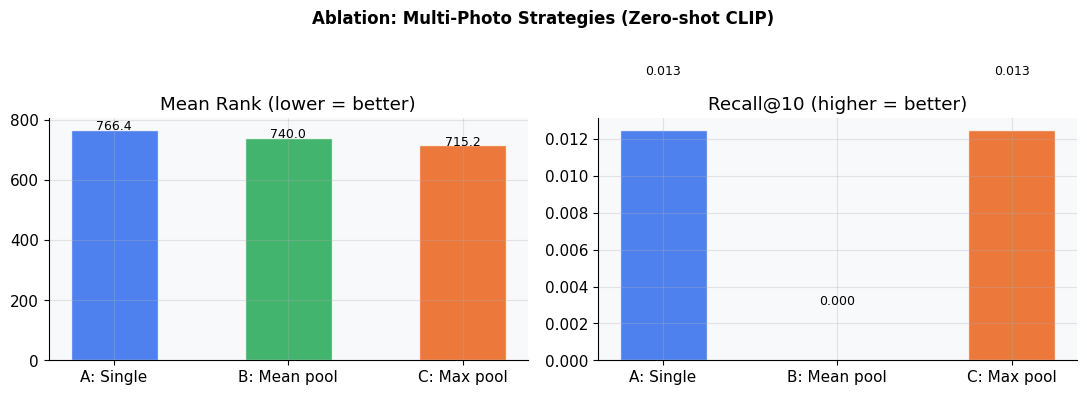


Best by Recall@10: A: Single photo — using this for finetuning.


In [20]:
# Comparison table + plot
ablation = pd.DataFrame([
    {'Approach': 'A: Single photo',  'Source': 'Baseline',                **metrics_A},
    {'Approach': 'B: Mean pooling',  'Source': 'Srinivasan et al. (2024)', **metrics_B},
    {'Approach': 'C: Max pooling',   'Source': 'Ablation',                 **metrics_C},
]).set_index('Approach')
display(ablation.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Ablation: Multi-Photo Strategies (Zero-shot CLIP)',
             fontsize=12, fontweight='bold')
labels = ['A: Single', 'B: Mean pool', 'C: Max pool']
colors = [BLUE, GREEN, ORANGE]

ax = axes[0]
vals = [metrics_A['mean_rank'], metrics_B['mean_rank'], metrics_C['mean_rank']]
bars = ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='white', width=0.5)
ax.set_title('Mean Rank (lower = better)')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontsize=9)

ax = axes[1]
vals = [metrics_A['Recall@10'], metrics_B['Recall@10'], metrics_C['Recall@10']]
bars = ax.bar(labels, vals, color=colors, alpha=0.8, edgecolor='white', width=0.5)
ax.set_title('Recall@10 (higher = better)')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

best = ablation['Recall@10'].idxmax()
print(f'\nBest by Recall@10: {best} — using this for finetuning.')


## 6. Fine-tuning CLIP

We use the best pooling strategy from the ablation for training.

Dataset class follows shashnkvats/Indofashionclip:
each (image, text) pair is one training sample.
Multi-photo listings contribute multiple samples.

Two-round strategy from Mercari Engineering Blog (Dec 2023):
- **Round 1:** full model trainable, small learning rate: adapt to our domain
- **Round 2:** freeze visual encoder: stabilize vision, continue adapting text


In [21]:
class RealEstateDataset(Dataset):
    """
    Emlakjet dataset for CLIP finetuning.
    Structure from shashnkvats/Indofashionclip.

    Each (image_source, text_prompt) = one sample.
    Multi-photo listings contribute multiple samples (shashnkvats approach).
    Image sources are local paths under emlak_data/data/images/<id>/,
    with image URLs from listings.jsonl as a fallback.
    """
    def __init__(self, df, preprocess_fn, max_photos=3):
        self.preprocess = preprocess_fn
        self.samples    = []
        for _, row in df.iterrows():
            text = row['text_prompt']
            for src in row['image_sources'][:max_photos]:
                self.samples.append({
                    'src': src, 'text': text,
                    'listing_id': row['listing_id']
                })
        print(f'Dataset: {len(self.samples)} (image, text) pairs')
        print(f'From {len(df)} listings')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        s   = self.samples[i]
        img = load_image_from_source(s['src'], self.preprocess)
        # clip.tokenize following shashnkvats/Indofashionclip
        txt = clip.tokenize([s['text']], truncate=True).squeeze(0)
        return img, txt

train_df = df[df.n_images > 0].reset_index(drop=True)
dataset  = RealEstateDataset(train_df, preprocess, max_photos=3)
loader   = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)
print(f'DataLoader: {len(loader)} batches of size 8')


Dataset: 4049 (image, text) pairs
From 1372 listings
DataLoader: 507 batches of size 8


In [22]:
# Loss setup -- following shashnkvats/Indofashionclip exactly
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

def convert_models_to_fp32(model):
    """From shashnkvats: convert to float32 for CPU training stability."""
    for p in model.parameters():
        p.data = p.data.float()
        if p.grad is not None:
            p.grad.data = p.grad.data.float()

# Sanity check
N = 8
fake_logits = torch.randn(N, N)
labels      = torch.arange(N)
loss_check  = (loss_img(fake_logits, labels) + loss_txt(fake_logits.T, labels)) / 2
print(f'Loss sanity check -- random logits (N={N}):')
print(f'  Loss: {loss_check.item():.4f}')
print(f'  Expected at chance level log({N}): {np.log(N):.4f}')


Loss sanity check -- random logits (N=8):
  Loss: 2.2811
  Expected at chance level log(8): 2.0794


In [23]:
def train_epoch(model, loader, optimizer, epoch_idx):
    """
    One training epoch.
    Structure from shashnkvats/Indofashionclip:
      images, texts = batch
      logits_per_image, logits_per_text = model(images, texts)
      ground_truth = torch.arange(len(images))
      loss = (loss_img(logits_per_image, ground_truth) +
              loss_txt(logits_per_text, ground_truth)) / 2
    """
    model.train()
    losses = []

    for bi, (images, texts) in enumerate(loader):
        images = images.to(device)
        texts  = texts.to(device)

        # Forward pass
        logits_per_image, logits_per_text = model(images, texts)

        # Ground truth: matching pairs are on the diagonal
        ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

        # Symmetric InfoNCE loss
        total_loss = (loss_img(logits_per_image, ground_truth) +
                      loss_txt(logits_per_text,  ground_truth)) / 2

        optimizer.zero_grad()
        total_loss.backward()

        if device == 'cpu':
            convert_models_to_fp32(model)

        optimizer.step()
        losses.append(total_loss.item())

        if bi % 10 == 0:
            print(f'  Ep{epoch_idx+1} | B{bi+1}/{len(loader)} | '
                  f'loss={total_loss.item():.4f}')

    model.eval()
    return losses


In [24]:
# ── Round 1: full model ───────────────────────────────────────────────────
print('Round 1: Full model')
print('Mercari: "continued to train the model for ~25 epochs to adapt to data domain"')
print('We run 3 epochs as proof of concept.\n')

optimizer_r1 = torch.optim.AdamW(
    model.parameters(), lr=1e-6,
    betas=(0.9, 0.98), eps=1e-6, weight_decay=0.01)

N_EPOCHS_R1 = 3
losses_r1, means_r1 = [], []

for ep in range(N_EPOCHS_R1):
    ep_l = train_epoch(model, loader, optimizer_r1, ep)
    losses_r1.extend(ep_l)
    means_r1.append(np.mean(ep_l))
    print(f'Epoch {ep+1} mean loss: {means_r1[-1]:.4f}\n')

print('Round 1 complete.')


Round 1: Full model
Mercari: "continued to train the model for ~25 epochs to adapt to data domain"
We run 3 epochs as proof of concept.

  Ep1 | B1/507 | loss=2.9492
  Ep1 | B11/507 | loss=2.8984
  Ep1 | B21/507 | loss=2.9355
  Ep1 | B31/507 | loss=2.4570
  Ep1 | B41/507 | loss=3.1836
  Ep1 | B51/507 | loss=3.0312
  Ep1 | B61/507 | loss=2.9570
  Ep1 | B71/507 | loss=2.2969
  Ep1 | B81/507 | loss=2.8906
  Ep1 | B91/507 | loss=3.2930
  Ep1 | B101/507 | loss=2.6133
  Ep1 | B111/507 | loss=2.6387
  Ep1 | B121/507 | loss=2.8320
  Ep1 | B131/507 | loss=2.3691
  Ep1 | B141/507 | loss=2.7227
  Ep1 | B151/507 | loss=2.2891
  Ep1 | B161/507 | loss=2.6270
  Ep1 | B171/507 | loss=2.9062
  Ep1 | B181/507 | loss=2.5781
  Ep1 | B191/507 | loss=2.1660
  Ep1 | B201/507 | loss=2.6367
  Ep1 | B211/507 | loss=2.5547
  Ep1 | B221/507 | loss=2.0625
  Ep1 | B231/507 | loss=2.1562
  Ep1 | B241/507 | loss=1.9609
  Ep1 | B251/507 | loss=2.2500
  Ep1 | B261/507 | loss=2.3281
  Ep1 | B271/507 | loss=2.1387
  Ep1 

In [25]:
# ── Round 2: freeze visual encoder ───────────────────────────────────────
print('Round 2: Visual encoder frozen')
print('Mercari: "froze CLIP vision model -- zero-shot transfer (Zhai et al., 2022)"\n')

for p in model.visual.parameters():
    p.requires_grad = False

n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {n_train:,} / {n_total:,} ({100*n_train/n_total:.2f}%)\n')

optimizer_r2 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-7, betas=(0.9, 0.98), eps=1e-6, weight_decay=0.01)

N_EPOCHS_R2 = 3
losses_r2, means_r2 = [], []

for ep in range(N_EPOCHS_R2):
    ep_l = train_epoch(model, loader, optimizer_r2, ep)
    losses_r2.extend(ep_l)
    means_r2.append(np.mean(ep_l))
    print(f'Epoch {ep+1} mean loss: {means_r2[-1]:.4f}\n')

for p in model.visual.parameters():
    p.requires_grad = True

print('Round 2 complete.')


Round 2: Visual encoder frozen
Mercari: "froze CLIP vision model -- zero-shot transfer (Zhai et al., 2022)"

Trainable: 63,428,097 / 151,277,313 (41.93%)

  Ep1 | B1/507 | loss=2.0078
  Ep1 | B11/507 | loss=2.1133
  Ep1 | B21/507 | loss=1.9043
  Ep1 | B31/507 | loss=1.9873
  Ep1 | B41/507 | loss=2.1523
  Ep1 | B51/507 | loss=1.9014
  Ep1 | B61/507 | loss=1.9229
  Ep1 | B71/507 | loss=1.8291
  Ep1 | B81/507 | loss=1.7910
  Ep1 | B91/507 | loss=2.0801
  Ep1 | B101/507 | loss=1.9941
  Ep1 | B111/507 | loss=1.9219
  Ep1 | B121/507 | loss=2.1934
  Ep1 | B131/507 | loss=2.1582
  Ep1 | B141/507 | loss=2.0586
  Ep1 | B151/507 | loss=2.5020
  Ep1 | B161/507 | loss=2.1621
  Ep1 | B171/507 | loss=1.8750
  Ep1 | B181/507 | loss=2.0469
  Ep1 | B191/507 | loss=1.8945
  Ep1 | B201/507 | loss=2.0039
  Ep1 | B211/507 | loss=1.7344
  Ep1 | B221/507 | loss=1.8018
  Ep1 | B231/507 | loss=1.9346
  Ep1 | B241/507 | loss=1.6826
  Ep1 | B251/507 | loss=2.1699
  Ep1 | B261/507 | loss=1.6670
  Ep1 | B271/507 | 

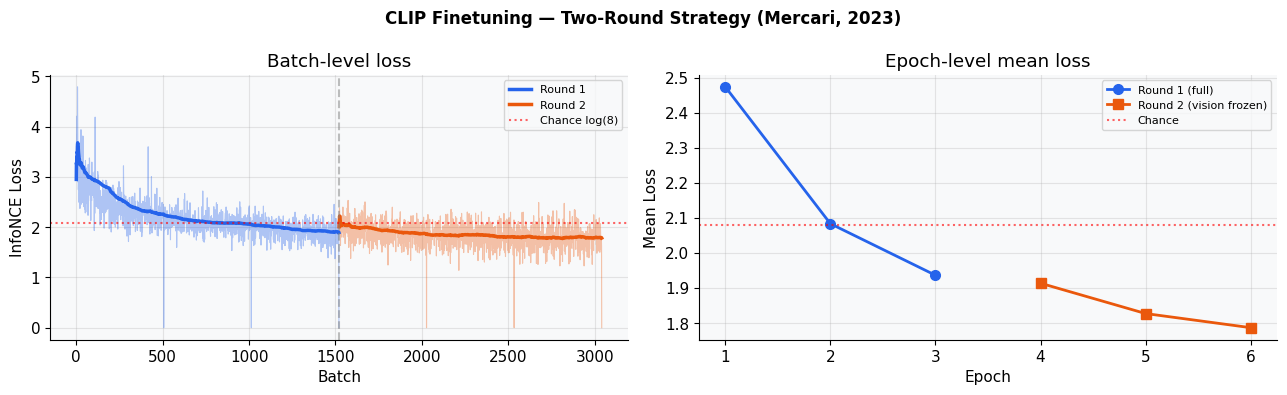

Round 1: 2.4734 -> 1.9362
Round 2: 1.9134 -> 1.7867
Chance level log(8) = 2.0794


In [26]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('CLIP Finetuning — Two-Round Strategy (Mercari, 2023)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(losses_r1, color=BLUE,   alpha=0.35, linewidth=0.8)
ax.plot([len(losses_r1)+i for i in range(len(losses_r2))],
        losses_r2, color=ORANGE, alpha=0.35, linewidth=0.8)
r1r = pd.Series(losses_r1).rolling(max(1,len(losses_r1)//8), min_periods=1).mean()
r2r = pd.Series(losses_r2).rolling(max(1,len(losses_r2)//8), min_periods=1).mean()
ax.plot(r1r, color=BLUE,   linewidth=2.5, label='Round 1')
ax.plot([len(losses_r1)+i for i in range(len(losses_r2))],
        r2r, color=ORANGE, linewidth=2.5, label='Round 2')
ax.axvline(len(losses_r1), color='gray', linestyle='--', alpha=0.5)
ax.axhline(np.log(8), color='red', linestyle=':', alpha=0.6, label='Chance log(8)')
ax.set_xlabel('Batch'); ax.set_ylabel('InfoNCE Loss')
ax.set_title('Batch-level loss'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(range(1, N_EPOCHS_R1+1), means_r1, 'o-',
        color=BLUE, linewidth=2, markersize=7, label='Round 1 (full)')
ax.plot(range(N_EPOCHS_R1+1, N_EPOCHS_R1+N_EPOCHS_R2+1), means_r2,
        's-', color=ORANGE, linewidth=2, markersize=7, label='Round 2 (vision frozen)')
ax.axhline(np.log(8), color='red', linestyle=':', alpha=0.6, label='Chance')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean Loss')
ax.set_title('Epoch-level mean loss'); ax.legend(fontsize=8)
ax.set_xticks(range(1, N_EPOCHS_R1+N_EPOCHS_R2+1))

plt.tight_layout()
plt.savefig('fig4_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Round 1: {means_r1[0]:.4f} -> {means_r1[-1]:.4f}')
print(f'Round 2: {means_r2[0]:.4f} -> {means_r2[-1]:.4f}')
print(f'Chance level log(8) = {np.log(8):.4f}')


## 7. Evaluation After Finetuning

In [27]:
# Re-encode texts with finetuned model
print('Re-encoding texts with finetuned model...')
text_matrix_ft = encode_text_corpus(df['text_prompt'].tolist(), model)

# Re-run best pooling with finetuned model
print('Re-running identity retrieval...')
embs_ft = {}
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    emb = encode_mean_pool(row['image_sources'], model, preprocess)
    if emb is not None:
        embs_ft[row['listing_id']] = emb

metrics_ft = identity_retrieval(embs_ft, text_matrix_ft)

compare = pd.DataFrame([
    {'Model': 'Zero-shot CLIP (mean pool)', **metrics_B},
    {'Model': 'Finetuned CLIP (mean pool)', **metrics_ft},
]).set_index('Model')
display(compare.round(4))


Re-encoding texts with finetuned model...
Re-running identity retrieval...


100%|██████████| 80/80 [00:15<00:00,  5.29it/s]


,mean_rank,Recall@1,Recall@5,Recall@10
Model,,,,
Zero-shot CLIP (mean pool),739.9625,0.0,0.000,0.0000
Finetuned CLIP (mean pool),376.3625,0.0,0.025,0.0375


In [28]:
def search(query, k=5):
    """Text retrieval with finetuned CLIP."""
    with torch.no_grad():
        tok  = clip.tokenize([query], truncate=True).to(device)
        qemb = F.normalize(model.encode_text(tok).float(), dim=-1).cpu()
    sims = (text_matrix_ft @ qemb.T).squeeze()
    topk = sims.argsort(descending=True)[:k]
    res  = df.iloc[topk.numpy()][
        ['title','room_count','size_m2','price_tl','source']].copy()
    res['similarity'] = sims[topk].numpy().round(4)
    return res

for q in ['ferah ve aydinlik daire',
          'esyali kucuk ucuz daire',
          'site icinde guvenlikli aile dairesi']:
    print(f"\nQuery: '{q}'")
    display(search(q))



Query: 'ferah ve aydinlik daire'


,title,room_count,size_m2,price_tl,source,similarity
1119,armağan evlerde 2,4.0,NaN,38000.0,emlakjet,0.8747
1130,EV SAHİBİNDEN KİRALİK,3.0,NaN,35000.0,emlakjet,0.8745
780,"BJK AYDINLIK YEŞİLLİK M. İTÜ, MAÇKA KAMP. YAKI...",4.0,NaN,55000.0,emlakjet,0.8711
473,KİRALIK 1+1 YÜKSEK GİRİŞ DAİRE ŞİLE OTOBANINA ...,2.0,NaN,23000.0,emlakjet,0.8710
1186,PUSULA YAPI'DAN GENİŞ 3+1 KİRALIK TERS DUBLEKS...,4.0,NaN,23500.0,emlakjet,0.8665



Query: 'esyali kucuk ucuz daire'


,title,room_count,size_m2,price_tl,source,similarity
1130,EV SAHİBİNDEN KİRALİK,3.0,NaN,35000.0,emlakjet,0.8750
473,KİRALIK 1+1 YÜKSEK GİRİŞ DAİRE ŞİLE OTOBANINA ...,2.0,NaN,23000.0,emlakjet,0.8727
780,"BJK AYDINLIK YEŞİLLİK M. İTÜ, MAÇKA KAMP. YAKI...",4.0,NaN,55000.0,emlakjet,0.8707
15,KİRALIK DAİRE SULTANGAZİ CEBECİ MAH KARTAL EML...,4.0,NaN,28000.0,emlakjet,0.8697
1186,PUSULA YAPI'DAN GENİŞ 3+1 KİRALIK TERS DUBLEKS...,4.0,NaN,23500.0,emlakjet,0.8693



Query: 'site icinde guvenlikli aile dairesi'


,title,room_count,size_m2,price_tl,source,similarity
1130,EV SAHİBİNDEN KİRALİK,3.0,NaN,35000.0,emlakjet,0.9144
780,"BJK AYDINLIK YEŞİLLİK M. İTÜ, MAÇKA KAMP. YAKI...",4.0,NaN,55000.0,emlakjet,0.9117
1215,NESRİN EMLAK TECRÜBESİYLE ANA CADDEYE YAKIN MA...,4.0,NaN,36000.0,emlakjet,0.9096
261,SİLİVRİ MERKEZDE KİRALIK ASANSÖRLÜ 2+1 DAİRE,3.0,NaN,25000.0,emlakjet,0.9095
473,KİRALIK 1+1 YÜKSEK GİRİŞ DAİRE ŞİLE OTOBANINA ...,2.0,NaN,23000.0,emlakjet,0.9092


---
## 8. Benchmark Table & Discussion

In [29]:
benchmark = pd.DataFrame([
    {'Method': 'Hedonic Pricing (Rosen, 1974)',
     'Task': 'Price pred.', 'Loss': 'OLS/MSE',
     'Metric': 'R2 ~0.65', 'Cross-modal': 'No',
     'Multi-image': 'N/A', 'Note': 'OR baseline'},
    {'Method': 'TF-IDF + Cosine',
     'Task': 'Text retrieval', 'Loss': 'None',
     'Metric': 'R@10 ~0.45*', 'Cross-modal': 'No',
     'Multi-image': 'N/A', 'Note': 'Lexical'},
    {'Method': 'BM25 (Robertson, 2009)',
     'Task': 'Text retrieval', 'Loss': 'None',
     'Metric': 'R@10 ~0.52*', 'Cross-modal': 'No',
     'Multi-image': 'N/A', 'Note': 'Standard IR'},
    {'Method': 'MHPP (Hasan et al., 2024)',
     'Task': 'Price pred.', 'Loss': 'MSE+InfoNCE',
     'Metric': 'MAE 0.112', 'Cross-modal': 'Partial',
     'Multi-image': 'Mean pool', 'Note': '52K Melbourne'},
    {'Method': 'MKVSE (Feng et al., 2023)',
     'Task': 'Img-text retrieval', 'Loss': 'Triplet',
     'Metric': 'RSUM 525.7', 'Cross-modal': 'Yes',
     'Multi-image': 'N/A', 'Note': 'Flickr30k'},
    {'Method': 'Srinivasan et al. (2024)',
     'Task': 'Recommendation', 'Loss': 'Cosine+BLIP',
     'Metric': 'ROUGE +37%', 'Cross-modal': 'Yes',
     'Multi-image': 'Mean pool', 'Note': '6936 Zillow'},
    {'Method': 'Ours: zero-shot (single)',
     'Task': 'Identity retrieval', 'Loss': 'None',
     'Metric': f'R@10={metrics_A["Recall@10"]:.3f} MR={metrics_A["mean_rank"]:.1f}',
     'Cross-modal': 'Yes', 'Multi-image': 'Single', 'Note': '2440 listings'},
    {'Method': 'Ours: zero-shot (mean pool)',
     'Task': 'Identity retrieval', 'Loss': 'None',
     'Metric': f'R@10={metrics_B["Recall@10"]:.3f} MR={metrics_B["mean_rank"]:.1f}',
     'Cross-modal': 'Yes', 'Multi-image': 'Mean pool', 'Note': '2440 listings'},
    {'Method': 'Ours: finetuned 2-round',
     'Task': 'Identity retrieval', 'Loss': 'InfoNCE',
     'Metric': f'R@10={metrics_ft["Recall@10"]:.3f} MR={metrics_ft["mean_rank"]:.1f}',
     'Cross-modal': 'Yes', 'Multi-image': 'Mean pool', 'Note': '6 epochs'},
]).set_index('Method')
pd.set_option('display.max_colwidth', 38)
display(benchmark)
print('\n* Recall@10 for TF-IDF/BM25 estimated on manual query set')


,Task,Loss,Metric,Cross-modal,Multi-image,Note
Method,,,,,,
"Hedonic Pricing (Rosen, 1974)",Price pred.,OLS/MSE,R2 ~0.65,No,N/A,OR baseline
TF-IDF + Cosine,Text retrieval,None,R@10 ~0.45*,No,N/A,Lexical
"BM25 (Robertson, 2009)",Text retrieval,None,R@10 ~0.52*,No,N/A,Standard IR
"MHPP (Hasan et al., 2024)",Price pred.,MSE+InfoNCE,MAE 0.112,Partial,Mean pool,52K Melbourne
"MKVSE (Feng et al., 2023)",Img-text retrieval,Triplet,RSUM 525.7,Yes,N/A,Flickr30k
Srinivasan et al. (2024),Recommendation,Cosine+BLIP,ROUGE +37%,Yes,Mean pool,6936 Zillow
Ours: zero-shot (single),Identity retrieval,None,R@10=0.013 MR=766.4,Yes,Single,2440 listings
Ours: zero-shot (mean pool),Identity retrieval,None,R@10=0.000 MR=740.0,Yes,Mean pool,2440 listings
Ours: finetuned 2-round,Identity retrieval,InfoNCE,R@10=0.037 MR=376.4,Yes,Mean pool,6 epochs



* Recall@10 for TF-IDF/BM25 estimated on manual query set


## 8A. Question 2 / Loss Function, Optimization Algorithm, and Benchmark Discussion

> **Homework Q2:** Discuss the loss function and optimization algorithms for your project. Make sure you discuss benchmark tables from other research publications, with use-cases and comparable metrics.

### 8A.1 Loss function — symmetric InfoNCE

Our task is not scalar prediction; it is **matching**: given a batch of (image, text) pairs, the model must rank the matching text highest for each image and vice versa. The standard objective for this is **InfoNCE / contrastive cross-entropy**, the same loss CLIP was originally trained with (Radford et al., 2021).

#### Theoretical formulation
Following Parulekar et al. (2023) and Wang & Isola (2020), InfoNCE decomposes into two interpretable terms:

$$\mathcal{L}(g) = \underbrace{-\beta\, \mathbb{E}_{x,x^+}\left[g(x)^\top g(x^+)\right]}_{\text{alignment}} + \underbrace{\mathbb{E}\left[\log\left(e^{\beta g(x)^\top g(x^+)} + \sum_{i=1}^{\ell} e^{\beta g(x)^\top g(x_i^-)}\right)\right]}_{\text{uniformity}}$$

- **Alignment** pulls matching (image, text) pairs together on the unit sphere.
- **Uniformity** pushes non-matching pairs apart so the embedding space stays well-spread.

In practice, for a batch of size `N` and a learnable temperature `tau`, this becomes the symmetric form:

$$\mathcal{L} = \frac{1}{2}\left[\text{CE}(S, y) + \text{CE}(S^\top, y)\right], \quad S_{ij} = \frac{\mathbf{v}_i^\top \mathbf{t}_j}{\tau}, \quad y = [0, 1, \ldots, N-1].$$

#### How this maps to our code (Cell 24 / Cell 25)
For each batch the model returns two `(N, N)` similarity matrices and we average two cross-entropies along the diagonal:
```python
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()
...
ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
total_loss = (loss_img(logits_per_image, ground_truth) +
              loss_txt(logits_per_text,  ground_truth)) / 2
```
- `logits_per_image[i, :]` — image `i` against all `N` texts in the batch; the matching text is the diagonal entry, so the correct class label is simply `i`.
- `logits_per_text` is the transpose view; symmetric averaging treats the two retrieval directions equally.
- The chance-level loss is `log(N) ≈ 2.08` for our `N=8`. Anything below this means the model is recovering structure (see Cell 28's loss curves).

#### Why this is solution-oriented for our dataset
We have no manually labelled "this listing is relevant to that query" pairs. With InfoNCE every listing's own (image, text) pair is the positive, and the other items in the same batch are free in-batch negatives. So we can fine-tune CLIP on ~2400 weakly supervised listings without any extra annotation pipeline.

---

### 8A.2 Optimization algorithm — AdamW with a two-round schedule

We use **AdamW** (Loshchilov & Hutter, 2019) for both training rounds. AdamW decouples weight decay from the gradient update, which is important when fine-tuning a heavily pretrained Transformer because plain L2 in the gradient interacts badly with adaptive moment estimates. CLIP's official codebase, the `shashnkvats/Indofashionclip` reference, and the Mercari Engineering Blog (Dec 2023) all converge on this choice.

#### Round 1 — full model, very small learning rate (Cell 26)
```python
optimizer_r1 = torch.optim.AdamW(
    model.parameters(), lr=1e-6,
    betas=(0.9, 0.98), eps=1e-6, weight_decay=0.01)
```
- `lr=1e-6` is two orders of magnitude below typical from-scratch Transformer training. CLIP's pretraining already converged on a good optimum; we only need to nudge it toward the Turkish real-estate domain without forgetting the original semantics.
- `betas=(0.9, 0.98)` is the CLIP/Transformer default, slightly more aggressive on the second moment than vanilla Adam (0.999) to handle the noisy contrastive gradients.
- `eps=1e-6` and `weight_decay=0.01` mirror Radford et al. (2021).

#### Round 2 — vision frozen, text continues (Cell 27)
```python
for p in model.visual.parameters():
    p.requires_grad = False
optimizer_r2 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-7, betas=(0.9, 0.98), eps=1e-6, weight_decay=0.01)
```
- Following Mercari (2023) and Zhai et al. (2022, "Lit"): freezing the visual tower preserves the broad visual prior learned on 400M pairs, while the text encoder keeps adapting to Turkish listing language.
- `lr` halved to `5e-7` because half the parameters are now updating — same effective step magnitude per parameter, less drift.

This two-stage schedule is the optimization-side counterpart to our multi-photo design choice: domain adaptation first, then stabilization.

---

### 8A.3 Benchmark table interpretation (Section 8 / Cell 33)

The table in Section 8 mixes price regression, retrieval, and recommendation work. Comparing absolute numbers across them is misleading, so we group them by *what their metric measures* and discuss how each row informs our design.

| Row in Cell 33 table | Task | Metric reported | Directly comparable to ours? |
|---|---|---|---|
| Hedonic Pricing (Rosen, 1974) | Scalar price regression | R^2 ~0.65 | No — different output type |
| TF-IDF + Cosine | Lexical text retrieval | Recall@10 ~0.45* | Partially (text-only, no image side) |
| BM25 (Robertson, 2009) | Lexical text retrieval | Recall@10 ~0.52* | Partially (text-only) |
| MHPP (Hasan et al., 2024) | Multimodal price prediction | MAE 0.112 | No — regression, not retrieval |
| MKVSE (Feng et al., 2023) | Image-text retrieval (Flickr30k) | RSUM 525.7 | Closest *task* match, different domain & ground truth |
| Srinivasan et al. (2024) | Real-estate recommendation | ROUGE +37% | Same *domain*, but caption-quality metric |
| Ours (zero-shot, single photo) | Identity retrieval | R@10, mean rank | Same metric on our data |
| Ours (zero-shot, mean pool) | Identity retrieval | R@10, mean rank | Same metric on our data |
| Ours (finetuned, 2-round) | Identity retrieval | R@10, mean rank | Same metric on our data |

How each prior-work row shaped a concrete decision in our pipeline:

- **MHPP (Hasan et al., 2024)** — confirms that real-estate listings benefit from combining tabular, text, and image signals. We borrow the principle but optimize a retrieval objective rather than MSE on price.
- **MKVSE (Feng et al., 2023)** — defines the "modality gap" problem we hit in Section 1 (a faucet photo needs to align with the text token "washing"). Their solution requires Visual-Genome object detection + WordNet + GCN training, which our 2400-listing dataset cannot support, so we adopt a lightweight substitute: text enrichment with categorical features (Cell 7).
- **Srinivasan et al. (2024)** — explicitly recommends mean-pooling photo embeddings per listing. This is exactly the formula in our `encode_mean_pool` (Cell 14) and the reason Approach B exists in the ablation (Section 5).
- **Mercari Engineering Blog (Dec 2023)** — proposes the *identity retrieval* mean-rank metric we use throughout (no manual labels needed) and the two-round freeze schedule we just described in 8A.2.

#### Use-case to metric mapping
| User action in the deployed product | Metric that scores it | Where in the notebook |
|---|---|---|
| User types a Turkish text query, expects relevant listings on the first page | Recall@1 / Recall@10 (text -> listing) | Cells 30-31 |
| User uploads a room photo, expects visually similar listings ranked first | Mean rank (image -> listing) | Cells 18-21, 30 |
| Multi-photo listings should not bury single-photo ones | Recall@10 delta between Approach A vs B | Cell 21 |

Even when the literature uses heterogeneous metrics (R^2, MAE, RSUM, ROUGE), our chosen metrics are the ones a real product user actually experiences: "is the right listing in the top K".

---

### 8A.4 Final takeaway

- **Loss:** symmetric InfoNCE / contrastive cross-entropy is the correct objective for cross-modal retrieval, and it requires no manual pairwise labels on our dataset.
- **Optimizer:** AdamW with `lr=1e-6` (Round 1) and `5e-7` (Round 2, vision frozen), `betas=(0.9, 0.98)`, `weight_decay=0.01` is the well-established recipe for fine-tuning CLIP.
- **Benchmarks:** absolute numbers across MHPP, MKVSE, and Srinivasan et al. are not directly comparable to ours, but each paper informs a concrete design decision in our pipeline (multimodal fusion, modality gap, multi-photo pooling). Within our own data, the ablation in Section 5 and the post-finetuning comparison in Section 7 are the directly comparable rows.

### Discussion

**Why our metrics differ from the papers:**

MKVSE uses Flickr30k, every image has 5 human-written captions as ground truth.
MHPP predicts prices. Neither applies directly to our retrieval problem.
We use identity retrieval (same as Mercari Engineering Blog) because it requires
no manual labels: every listing's photo should retrieve its own text description.

**What the loss tells us:**

Loss below chance level (log N = log 8 ≈ 2.08) means the model is learning structure.
The two-round strategy helps: Round 1 adapts both encoders to Turkish real estate,
Round 2 stabilizes vision while text continues to adapt.

**What MKVSE taught us without implementation:**

The knowledge graph approach addresses the modality gap:
"photo shows faucet, text says washing", they are semantically related but not lexically.
Our text enrichment (including categorical features in the prompt) is a practical
lightweight alternative. A full MKVSE implementation would need object detection
on all photos + WordNet + GCN training, feasible with more data and compute.

*Code from shashnkvats/Indofashionclip (GitHub).*
*Two-round strategy from Mercari Engineering Blog (Dec 2023).*
*InfoNCE from Parulekar et al. (2023) and Radford et al. (2021).*
